In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score,root_mean_squared_error,mean_absolute_error

In [2]:
main_df = pd.read_csv("/Users/utkuseyithanoglu/Desktop/nyc car crash analysis/utku-explo/clean_crash_data.csv")

In [3]:
main_df.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,...,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,day_of_week,is_weekend,hour,injury_flag,vehicle_category
0,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,...,0,1,0,Unspecified,4675373,2,0,1,1,Other
1,2021-09-11,9:35,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,...,0,0,0,Unspecified,4456314,5,1,9,0,Car
2,2021-12-14,8:13,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,...,0,0,0,Unspecified,4486609,1,0,8,0,Other
3,2021-12-14,17:05,UNKNOWN,0,40.709183,-73.956825,0.0,0.0,0,0,...,0,0,0,Passing Too Closely,4486555,1,0,17,0,Car
4,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,...,0,2,0,Unspecified,4486660,1,0,8,1,Car


In [4]:
main_df.isna().sum()

CRASH DATE                       0
CRASH TIME                       0
BOROUGH                          0
ZIP CODE                         0
LATITUDE                         0
LONGITUDE                        0
NUMBER OF PERSONS INJURED        0
NUMBER OF PERSONS KILLED         0
NUMBER OF PEDESTRIANS INJURED    0
NUMBER OF PEDESTRIANS KILLED     0
NUMBER OF CYCLIST INJURED        0
NUMBER OF CYCLIST KILLED         0
NUMBER OF MOTORIST INJURED       0
NUMBER OF MOTORIST KILLED        0
CONTRIBUTING FACTOR VEHICLE 1    0
COLLISION_ID                     0
day_of_week                      0
is_weekend                       0
hour                             0
injury_flag                      0
vehicle_category                 0
dtype: int64

In [5]:
main_df['datetime'] = pd.to_datetime(main_df['CRASH DATE'] + " " + main_df['CRASH TIME'])

In [6]:
main_df = main_df.drop(columns=['CRASH DATE','CRASH TIME'])

In [7]:
main_df =main_df.set_index(['datetime'])

In [8]:
main_df

,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,day_of_week,is_weekend,hour,injury_flag,vehicle_category
datetime,,,,,,,,,,,,,,,,,,,
2023-11-01 01:29:00,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,0,0,1,0,Unspecified,4675373,2,0,1,1,Other
2021-09-11 09:35:00,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,0,0,0,0,Unspecified,4456314,5,1,9,0,Car
2021-12-14 08:13:00,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,0,0,0,0,Unspecified,4486609,1,0,8,0,Other
2021-12-14 17:05:00,UNKNOWN,0,40.709183,-73.956825,0.0,0.0,0,0,0,0,0,0,Passing Too Closely,4486555,1,0,17,0,Car
2021-12-14 08:17:00,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,0,0,2,0,Unspecified,4486660,1,0,8,1,Car
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-03 12:40:00,BRONX,10453,40.854816,-73.911500,3.0,0.0,0,0,0,0,3,0,Driver Inattention/Distraction,4882931,1,0,12,1,Other
2026-03-03 19:19:00,UNKNOWN,0,40.665520,-73.744670,0.0,0.0,0,0,0,0,0,0,Following Too Closely,4882837,1,0,19,0,SUV
2026-02-28 23:50:00,MANHATTAN,10002,40.721798,-73.988240,0.0,0.0,0,0,0,0,0,0,Unspecified,4883299,5,1,23,0,SUV


In [9]:
hourly_counts = main_df.resample('H').size()
main_df['crash_count'] = main_df.index.floor('H').map(hourly_counts)

/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_11327/1686324574.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_counts = main_df.resample('H').size()
/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_11327/1686324574.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  main_df['crash_count'] = main_df.index.floor('H').map(hourly_counts)


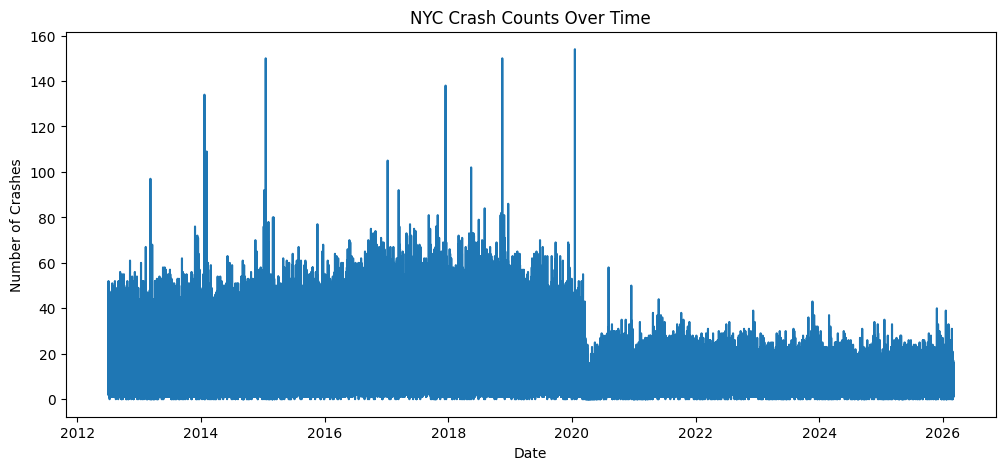

In [10]:
plt.figure(figsize=(12,5))
sns.lineplot(main_df.resample("h").size())
plt.title("NYC Crash Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Crashes")
plt.show()


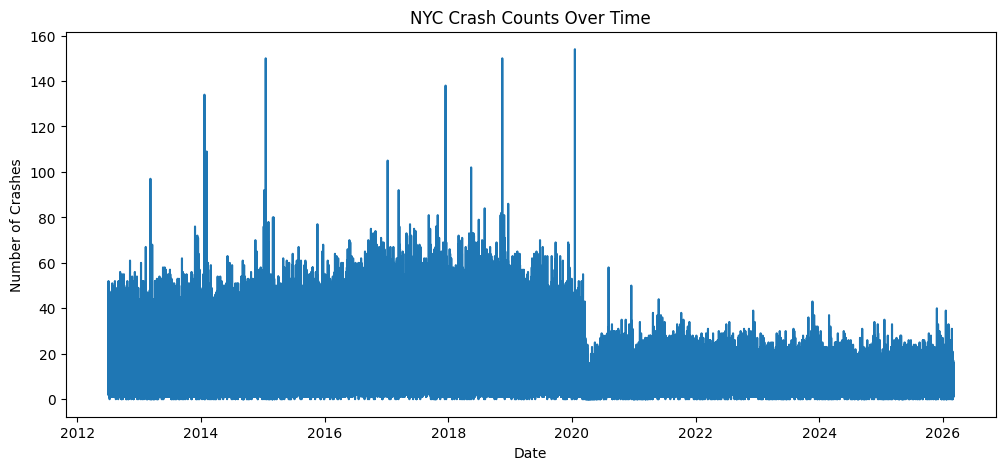

In [11]:
plt.figure(figsize=(12,5))
sns.lineplot(main_df.resample("h").size())
plt.title("NYC Crash Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Crashes")
plt.show()


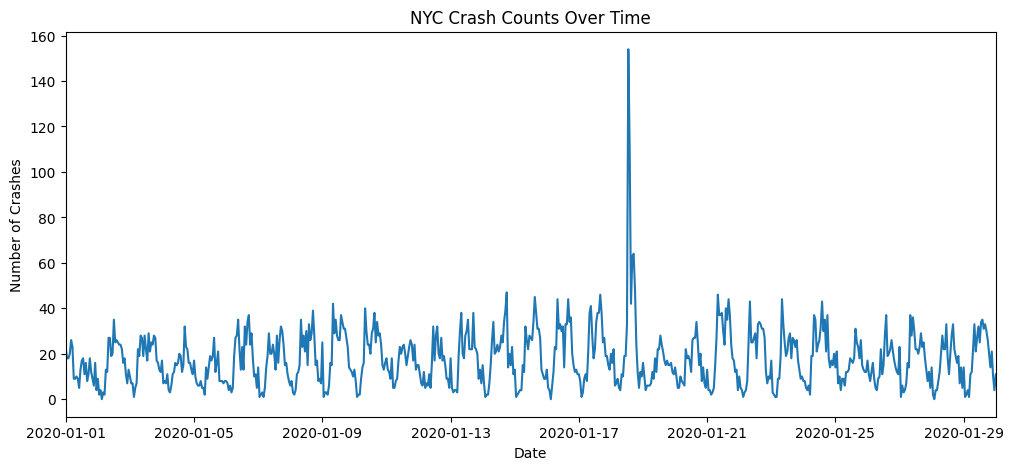

In [12]:
plt.figure(figsize=(12,5))
sns.lineplot(main_df.resample("h").size())
plt.title("NYC Crash Counts Over Time")
plt.xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-01-30"))
plt.xlabel("Date")
plt.ylabel("Number of Crashes")
plt.show()


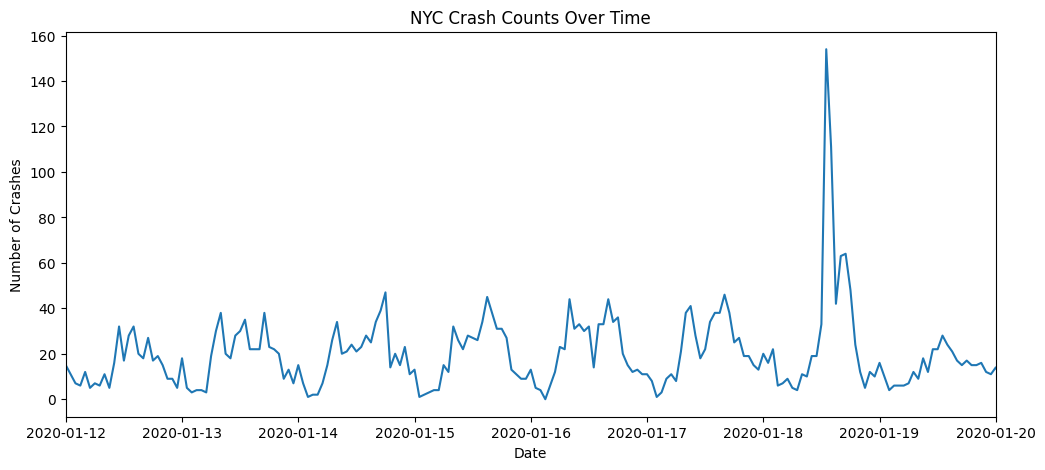

In [13]:
plt.figure(figsize=(12,5))
sns.lineplot(main_df.resample("h").size())
plt.title("NYC Crash Counts Over Time")
plt.xlim(pd.Timestamp("2020-01-12"), pd.Timestamp("2020-01-20"))
plt.xlabel("Date")
plt.ylabel("Number of Crashes")
plt.show()

In [14]:
main_df.resample("h").size().sort_values(ascending=False).head()


datetime
2020-01-18 13:00:00    154
2015-01-18 08:00:00    150
2018-11-15 15:00:00    150
2017-12-15 17:00:00    138
2014-01-21 10:00:00    134
dtype: int64

Text(0.5, 1.0, 'Crash Counts with 30-Day Rolling Mean')

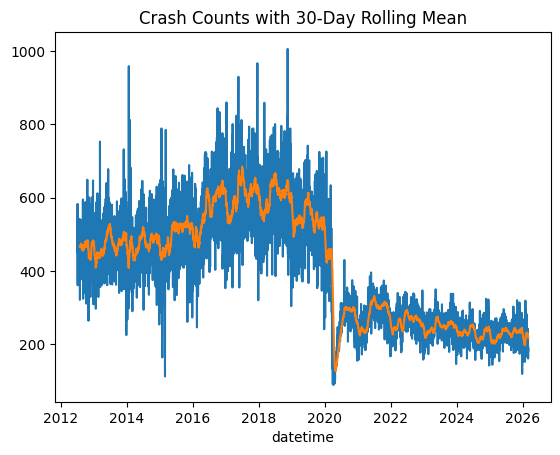

In [15]:
sns.lineplot(main_df.resample("D").size())
sns.lineplot(main_df.resample("D").size().rolling(30).mean())
plt.title("Crash Counts with 30-Day Rolling Mean")

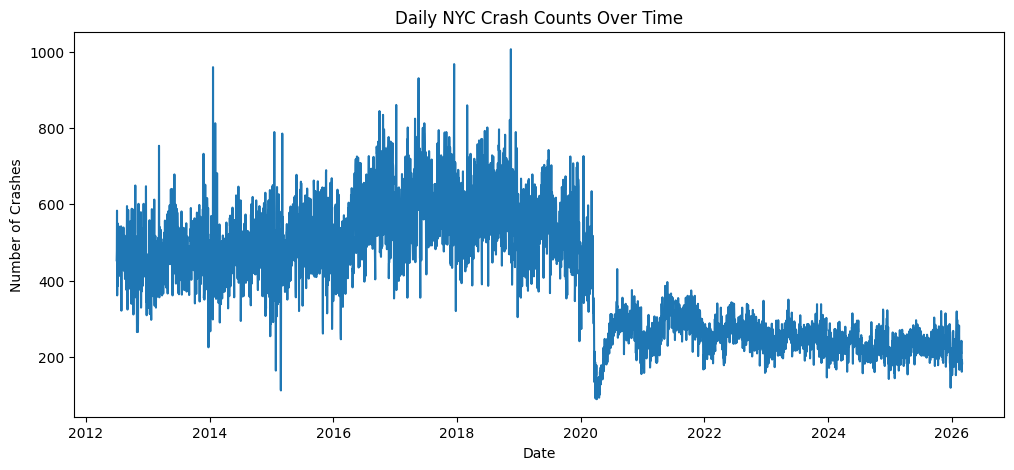

In [16]:
plt.figure(figsize=(12,5))
plt.plot(main_df.resample("D").size())
plt.title("Daily NYC Crash Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Crashes")
plt.show()


<Axes: xlabel='BOROUGH', ylabel='crash_count'>

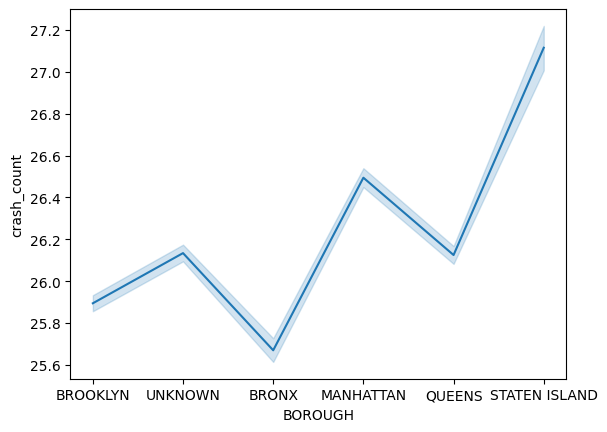

In [17]:
sns.lineplot(data=main_df,x='BOROUGH',y='crash_count')

<Axes: xlabel='BOROUGH', ylabel='crash_count'>

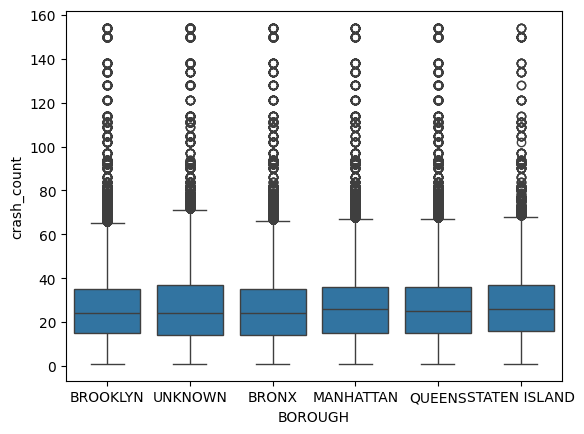

In [18]:
sns.boxplot(data=main_df,x='BOROUGH',y='crash_count')

Text(0, 0.5, 'Number of Crashes')

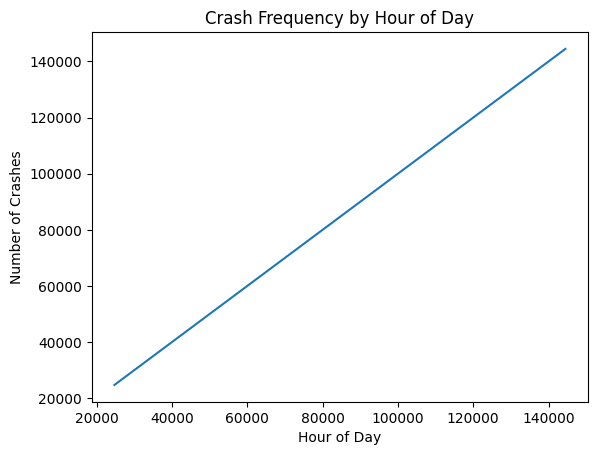

In [19]:
sns.lineplot(x=main_df.groupby('hour').size(),y=main_df.groupby('hour').size().values)
plt.title("Crash Frequency by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crashes")

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60],
 [Text(0, 0, 'Unspecified'),
  Text(1, 0, 'Passing Too Closely'),
  Text(2, 0, 'Driver Inexperience'),
  Text(3, 0, 'Passing or Lane Usage Improper'),
  Text(4, 0, 'Turning Improperly'),
  Text(5, 0, 'Unsafe Speed'),
  Text(6, 0, 'Reaction to Uninvolved Vehicle'),
  Text(7, 0, 'Steering Failure'),
  Text(8, 0, 'Following Too Closely'),
  Text(9, 0, 'Other Vehicular'),
  Text(10, 0, 'Driver Inattention/Distraction'),
  Text(11, 0, 'Oversized Vehicle'),
  Text(12, 0, 'Traffic Control Disregarded'),
  Text(13, 0, 'Alcohol Involvement'),
  Text(14, 0, 'View Obstructed/Limited'),
  Text(15, 0, 'Failure to Yield Right-of-Way'),
  Text(16, 0,

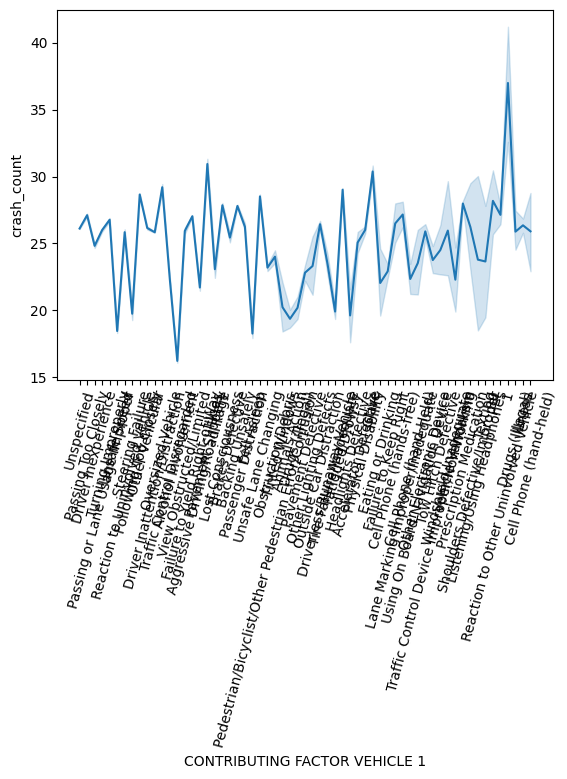

In [20]:
sns.lineplot(data=main_df,x='CONTRIBUTING FACTOR VEHICLE 1',y='crash_count')
plt.xticks(rotation=75)

In [21]:
time_df = main_df['crash_count']

In [22]:
time_df

datetime
2023-11-01 01:29:00     4
2021-09-11 09:35:00     8
2021-12-14 08:13:00    28
2021-12-14 17:05:00    23
2021-12-14 08:17:00    28
                       ..
2026-03-03 12:40:00     4
2026-03-03 19:19:00    16
2026-02-28 23:50:00     7
2026-03-03 22:15:00     8
2026-03-03 04:25:00     1
Name: crash_count, Length: 2036397, dtype: int64

In [23]:
(time_df.index).min()

Timestamp('2012-07-01 00:05:00')

In [24]:
(time_df.index).max()

Timestamp('2026-03-03 23:53:00')

In [25]:
time_df = main_df.resample("H").size().to_frame("crash_count")

/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_11327/1526203536.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_df = main_df.resample("H").size().to_frame("crash_count")


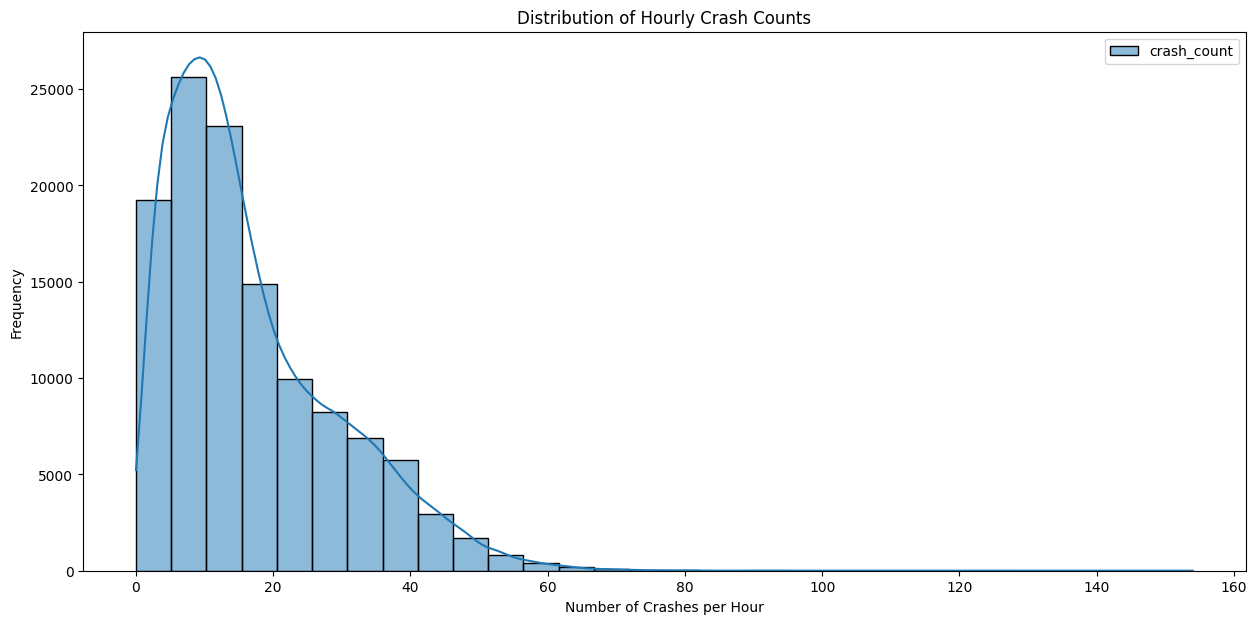

In [26]:
plt.figure(figsize=(15,7))
sns.histplot(time_df, bins=30, kde=True)
plt.title("Distribution of Hourly Crash Counts")
plt.xlabel("Number of Crashes per Hour")
plt.ylabel("Frequency")
plt.show()

<Axes: xlabel='datetime', ylabel='crash_count'>

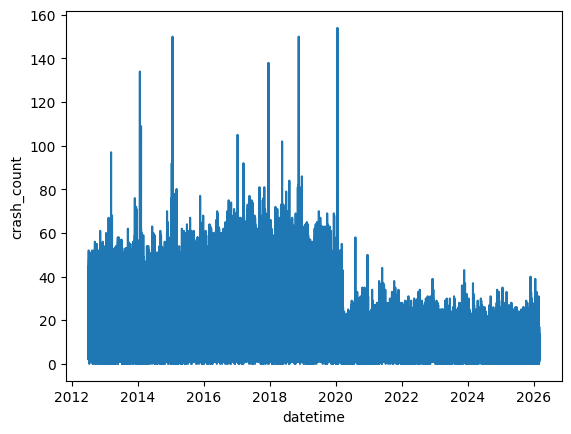

In [27]:
sns.lineplot(data=time_df, x=time_df.index, y="crash_count")


In [28]:
time_df.isna().sum()

crash_count    0
dtype: int64

In [29]:
time_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 119856 entries, 2012-07-01 00:00:00 to 2026-03-03 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   crash_count  119856 non-null  int64
dtypes: int64(1)
memory usage: 1.8 MB


(np.float64(15522.0), np.float64(15536.0))

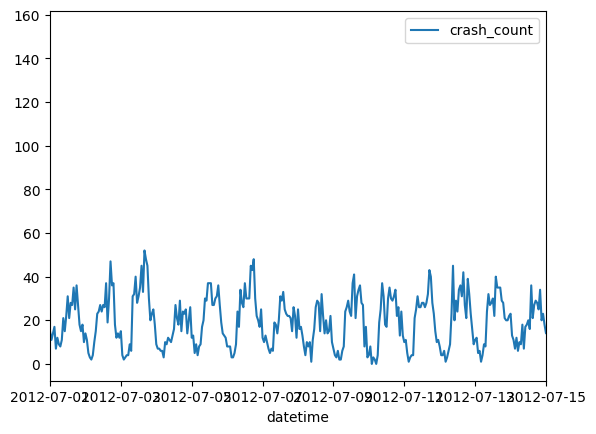

In [30]:
sns.lineplot(data=time_df)
plt.xlim(pd.Timestamp("2012-07-01"), pd.Timestamp("2012-07-15"))

(np.float64(15522.0), np.float64(15901.0))

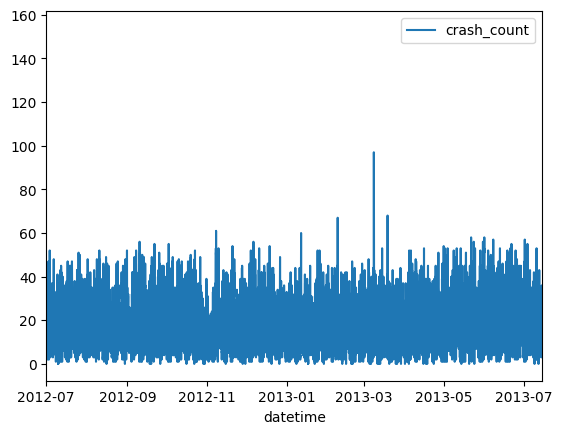

In [31]:
sns.lineplot(data=time_df)
plt.xlim(pd.Timestamp("2012-07-01"), pd.Timestamp("2013-07-15"))

(np.float64(15765.0), np.float64(15779.0))

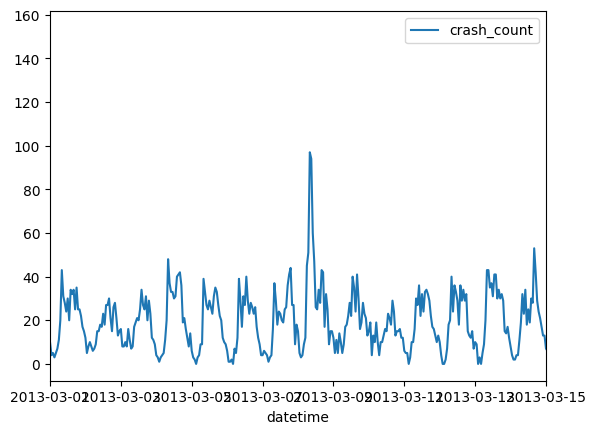

In [32]:
sns.lineplot(data=time_df)
plt.xlim(pd.Timestamp("2013-03-01"), pd.Timestamp("2013-03-15"))

In [33]:
time_df['diff'] = time_df['crash_count'].diff()

In [34]:
time_df['diff']

datetime
2012-07-01 00:00:00     NaN
2012-07-01 01:00:00    -4.0
2012-07-01 02:00:00     3.0
2012-07-01 03:00:00     3.0
2012-07-01 04:00:00   -10.0
                       ... 
2026-03-03 19:00:00     0.0
2026-03-03 20:00:00    -3.0
2026-03-03 21:00:00    -1.0
2026-03-03 22:00:00    -4.0
2026-03-03 23:00:00    -5.0
Freq: h, Name: diff, Length: 119856, dtype: float64

In [35]:
time_df['diff']=time_df['diff'].dropna()

In [36]:
time_df['diff'].mean()

np.float64(-0.00010012097951691628)

In [37]:
time_df['diff'].median()

np.float64(0.0)

In [38]:
time_df

,crash_count,diff
datetime,,
2012-07-01 00:00:00,15,NaN
2012-07-01 01:00:00,11,-4.0
2012-07-01 02:00:00,14,3.0
2012-07-01 03:00:00,17,3.0
2012-07-01 04:00:00,7,-10.0
...,...,...
2026-03-03 19:00:00,16,0.0
2026-03-03 20:00:00,13,-3.0
2026-03-03 21:00:00,12,-1.0


In [39]:
time_df.isna().sum()

crash_count    0
diff           1
dtype: int64

In [40]:
time_df = time_df.dropna()

In [41]:
time_df.isna().sum()

crash_count    0
diff           0
dtype: int64

<Axes: xlabel='datetime', ylabel='crash_count'>

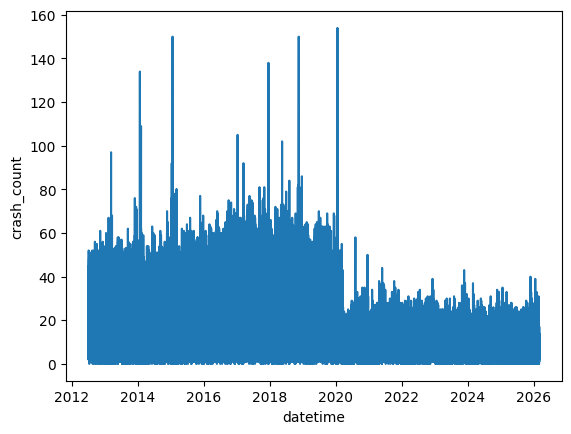

In [42]:
sns.lineplot(data=time_df,x=time_df.index,y='crash_count')

(np.float64(17956.0), np.float64(18276.0))

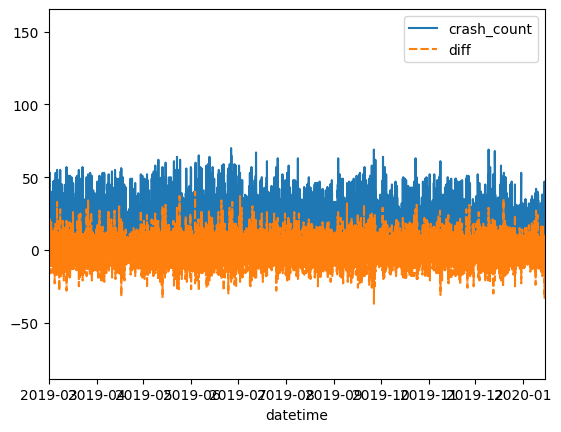

In [43]:
sns.lineplot(data=time_df)
plt.xlim(pd.Timestamp("2019-03-01"), pd.Timestamp("2020-01-15"))

<Axes: xlabel='datetime', ylabel='diff'>

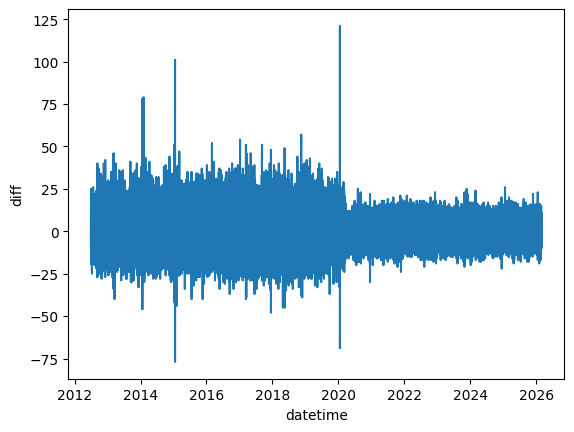

In [44]:
sns.lineplot(data=time_df, x=time_df.index, y='diff')

In [45]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [46]:
# Durum	Model
#Seasonal fark sabit	Additive
#Seasonal fark büyüyor	Multiplicative
#

In [47]:
decomposition = seasonal_decompose(time_df['crash_count'],model='Multiplicative',period=24)

In [48]:
decomposition

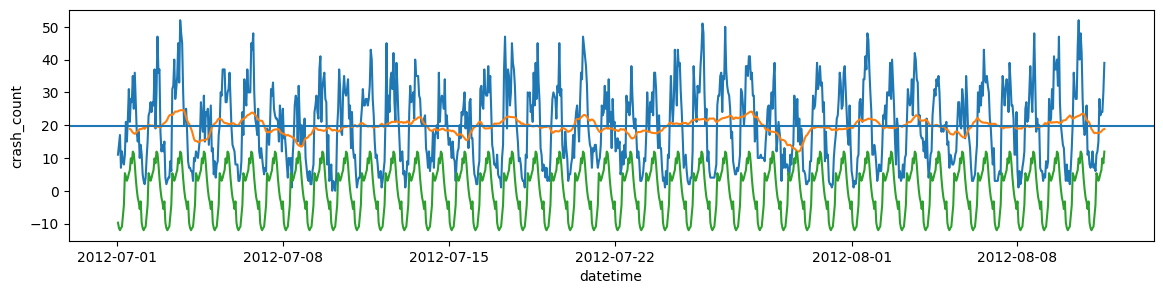

In [49]:
plt.figure(figsize=(14,3))
sns.lineplot(x=time_df.index[:1000],y=time_df['crash_count'][:1000])
sns.lineplot(x=decomposition.trend.index[:1000], y=decomposition.trend[:1000])
sns.lineplot(decomposition.seasonal[:1000])
plt.axhline(time_df['crash_count'][:1000].mean())

In [50]:
# Crash counts show a stable trend and a clear daily seasonal pattern.

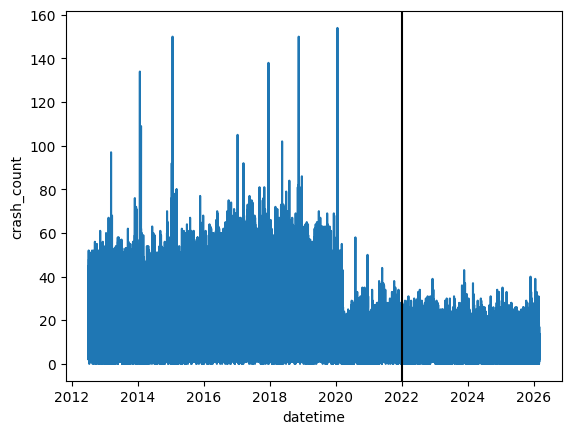

In [51]:
sns.lineplot(data=time_df,x=time_df.index,y='crash_count')
plt.axvline(pd.to_datetime('2022-01-01 12:00:00'), color='black',label='cutoff_date')

In [52]:
time_df.index.year.value_counts().sort_index()

datetime
2012    4415
2013    8760
2014    8760
2015    8760
2016    8784
2017    8760
2018    8760
2019    8760
2020    8784
2021    8760
2022    8760
2023    8760
2024    8784
2025    8760
2026    1488
Name: count, dtype: int64

In [53]:
time_df.resample("Y").size()

/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_11327/4161388618.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  time_df.resample("Y").size()


datetime
2012-12-31    4415
2013-12-31    8760
2014-12-31    8760
2015-12-31    8760
2016-12-31    8784
2017-12-31    8760
2018-12-31    8760
2019-12-31    8760
2020-12-31    8784
2021-12-31    8760
2022-12-31    8760
2023-12-31    8760
2024-12-31    8784
2025-12-31    8760
2026-12-31    1488
Freq: YE-DEC, dtype: int64

/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_11327/2129463820.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  time_df.resample("Y")["crash_count"].sum().plot(kind="bar")


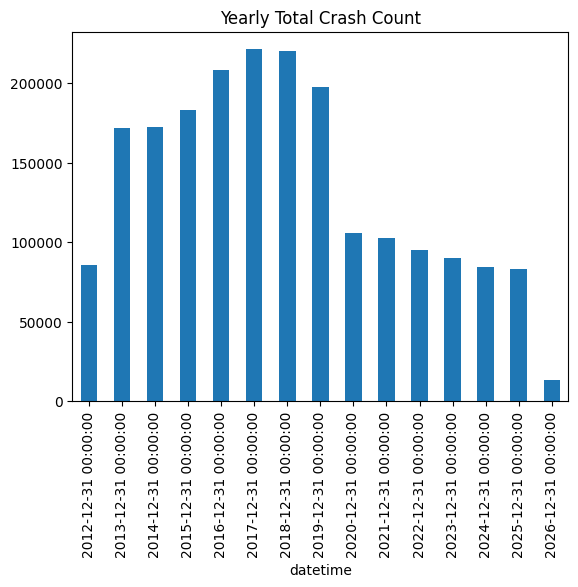

In [54]:
time_df.resample("Y")["crash_count"].sum().plot(kind="bar")
plt.title("Yearly Total Crash Count")
plt.show()

In [55]:
time_df.resample("Y")["crash_count"].sum()

/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_11327/889315695.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  time_df.resample("Y")["crash_count"].sum()


datetime
2012-12-31     85444
2013-12-31    171941
2014-12-31    172755
2015-12-31    183002
2016-12-31    208528
2017-12-31    221385
2018-12-31    220520
2019-12-31    197735
2020-12-31    105885
2021-12-31    103014
2022-12-31     95206
2023-12-31     90206
2024-12-31     84443
2025-12-31     82997
2026-12-31     13321
Freq: YE-DEC, Name: crash_count, dtype: int64

In [56]:
time_df['crash_count120'] = time_df['crash_count'].rolling(120).mean()

/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_11327/803718235.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_df['crash_count120'] = time_df['crash_count'].rolling(120).mean()


<Axes: xlabel='datetime', ylabel='crash_count120'>

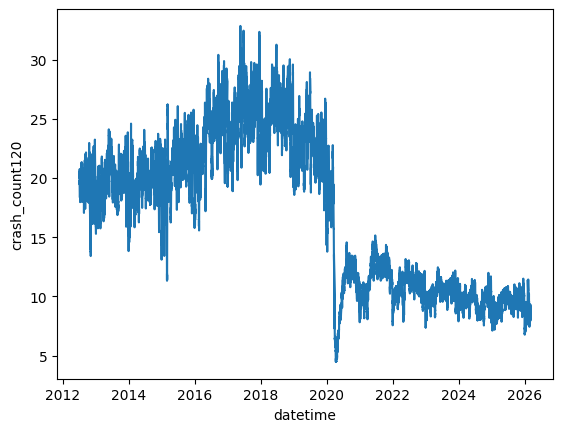

In [57]:
sns.lineplot(data= time_df,x=time_df.index,y="crash_count120")

In [58]:
time_df[time_df==0].sum()

crash_count       0.0
diff              0.0
crash_count120    0.0
dtype: float64

<Axes: xlabel='datetime'>

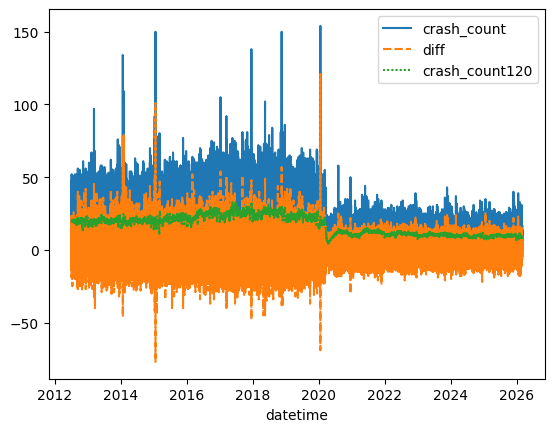

In [59]:
sns.lineplot(data=time_df)

In [60]:
time_df['diff'].describe()

count    119855.000000
mean         -0.000100
std           7.402412
min         -77.000000
25%          -4.000000
50%           0.000000
75%           4.000000
max         121.000000
Name: diff, dtype: float64

In [61]:
time_df['diff'].abs().sort_values(ascending=False).head()

datetime
2020-01-18 13:00:00    121.0
2015-01-18 07:00:00    101.0
2014-02-03 08:00:00     79.0
2014-01-21 09:00:00     78.0
2015-01-18 09:00:00     77.0
Name: diff, dtype: float64

In [62]:
cutoff_date = pd.to_datetime("2022-01-01 12:00:00")

In [63]:
time_df = time_df.drop(columns=["diff","crash_count120"])

In [64]:
time_df

,crash_count
datetime,
2012-07-01 01:00:00,11
2012-07-01 02:00:00,14
2012-07-01 03:00:00,17
2012-07-01 04:00:00,7
2012-07-01 05:00:00,12
...,...
2026-03-03 19:00:00,16
2026-03-03 20:00:00,13
2026-03-03 21:00:00,12


In [65]:
training_set= time_df[time_df.index< cutoff_date]
test_set = time_df[time_df.index >= cutoff_date]

In [66]:
training_set.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 83315 entries, 2012-07-01 01:00:00 to 2022-01-01 11:00:00
Freq: h
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   crash_count  83315 non-null  int64
dtypes: int64(1)
memory usage: 1.3 MB


In [67]:
training_set.isna().sum()

crash_count    0
dtype: int64

In [68]:
test_set.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 36540 entries, 2022-01-01 12:00:00 to 2026-03-03 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   crash_count  36540 non-null  int64
dtypes: int64(1)
memory usage: 570.9 KB


In [69]:
test_set.isna().sum()

crash_count    0
dtype: int64

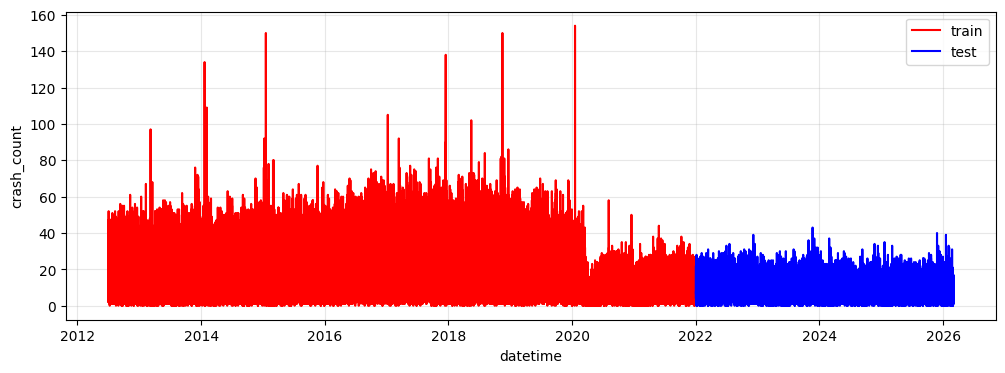

In [70]:
plt.figure(figsize=(12,4))

sns.lineplot(data=training_set, x=training_set.index, y='crash_count', label='train', color='red')
sns.lineplot(data=test_set,  x=test_set.index,  y='crash_count', label='test',  color='blue')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [71]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(training_set['crash_count'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -13.245416855828056
p-value: 8.99495381472394e-25


In [72]:
# 8.99e-25 = 0.000000000000000000000000899
#p < 0.05	stationary
#p > 0.05	non-stationary#

In [73]:
#
##
#ARIMA(p,d,q)
#d = 0
#Bu şu demek:
#Zaten seri stabil, fark almaya gerek yok.
#Eğer durağan olmasaydı:
#d=1 yapardık.

In [74]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [75]:
model = SARIMAX(training_set['crash_count'],order=(1,0,1),seasonal_order=(1,1,1,24))

In [76]:
model_fit = model.fit()

In [77]:
sarima_pred = model_fit.get_forecast(steps=len(test_set)).predicted_mean
sarima_pred.index = test_set.index

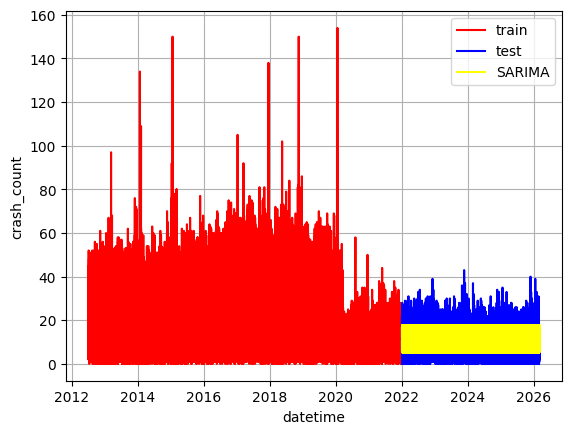

In [78]:
sns.lineplot(data=training_set, x=training_set.index, y='crash_count', label='train', color='red')
sns.lineplot(data=test_set,  x=test_set.index,  y='crash_count', label='test',  color='blue')
sns.lineplot(x=test_set.index,y=sarima_pred,color='yellow',label='SARIMA')
plt.grid()

## the line is too simillar

In [79]:
## otomatik parametreler

In [80]:
small_data = training_set['crash_count'][-1500:]

In [81]:
from pmdarima import auto_arima

In [82]:
#auto_model = auto_arima(small_data,
   #                     seasonal=True,
  #                      m=24,
 #                       trace=True)
#print(auto_model.summary())

In [83]:
# en kucuk aic
#  ARIMA(0,1,2)(0,0,2)[24]             : AIC=8945.365, Time=0.82 sec

In [84]:
#model2 = SARIMAX(training_set['crash_count'],order=(0,1,2),seasonal_order=(0,0,2,24))

In [85]:
#model2_fit = model2.fit()

In [86]:
# i tried but it didint went well

In [87]:
def model_evulation(actual_values,predict_values):
    print(f'root_mean_squared_error :{root_mean_squared_error(actual_values,predict_values)}')
    print(f'mean_squared_error :{mean_squared_error(actual_values,predict_values)}')
    print(f'mean_absolute_error :{mean_absolute_error(actual_values,predict_values)}')
    print(f'r2_score :{r2_score(actual_values,predict_values)}')

In [88]:
model_evulation(test_set['crash_count'], sarima_pred)

root_mean_squared_error :4.344685698907037
mean_squared_error :18.87629382228733
mean_absolute_error :3.507622339768019
r2_score :0.32251836308562876


In [89]:
baseline_pred = test_set['crash_count'].shift(24)

In [90]:
baseline_pred.isna().sum()

np.int64(24)

In [91]:
baseline_pred = baseline_pred.dropna()

In [92]:
baseline_actual = test_set['crash_count'].iloc[24:]

In [93]:
model_evulation(baseline_actual, baseline_pred)

root_mean_squared_error :5.283961973289893
mean_squared_error :27.92025413517362
mean_absolute_error :4.062000219082046
r2_score :-0.001972612180395794


In [94]:
# SARIMA performed better than the 24-hour baseline, i
# ndicating that the model captured hourly crash patterns more effectively.
 # Model, crash sayısındaki değişimin %32’sini açıklayabiliyor.
# Model tahminlerinin ortalama ne kadar hata yaptığını gösterir.

In [95]:
# mae ort hata
# rmse hatalarin karesi
# MSE’nin karekökü. hatalarin karekoku

In [96]:
tableau_df = pd.DataFrame({
    "datetime": test_set.index,
    "actual": test_set["crash_count"].values,
    "prediction": sarima_pred.values
})

# hata (çok önemli KPI için)
tableau_df["residual"] = tableau_df["actual"] - tableau_df["prediction"]
tableau_df["abs_error"] = abs(tableau_df["residual"])

# zaman featureları (Tableau’da filtre için süper önemli)
tableau_df["hour"] = tableau_df["datetime"].dt.hour
tableau_df["day"] = tableau_df["datetime"].dt.day
tableau_df["month"] = tableau_df["datetime"].dt.month
tableau_df["year"] = tableau_df["datetime"].dt.year
tableau_df["day_of_week"] = tableau_df["datetime"].dt.day_name()

# model etiketi (ileride başka model eklersen işe yarar)
tableau_df["model"] = "SARIMA"

# CSV kaydet
tableau_df.to_csv("tableau_sarima_final.csv", index=False)

print(tableau_df.head())

             datetime  actual  prediction  residual  abs_error  hour  day  \
0 2022-01-01 12:00:00       7   10.355135 -3.355135   3.355135    12    1   
1 2022-01-01 13:00:00       8    9.993303 -1.993303   1.993303    13    1   
2 2022-01-01 14:00:00      10   12.166293 -2.166293   2.166293    14    1   
3 2022-01-01 15:00:00      11   13.577684 -2.577684   2.577684    15    1   
4 2022-01-01 16:00:00       4   13.759761 -9.759761   9.759761    16    1   

   month  year day_of_week   model  
0      1  2022    Saturday  SARIMA  
1      1  2022    Saturday  SARIMA  
2      1  2022    Saturday  SARIMA  
3      1  2022    Saturday  SARIMA  
4      1  2022    Saturday  SARIMA  


Model tahminleri ortalama 3-4 crash hata yapıyor.

In [97]:
main_df['BOROUGH'].value_counts()

BOROUGH
BROOKLYN         498993
UNKNOWN          481797
QUEENS           416524
MANHATTAN        343626
BRONX            230307
STATEN ISLAND     65150
Name: count, dtype: int64

In [98]:
main_df =main_df[main_df['BOROUGH'].notna()].copy()


In [99]:
main_df= main_df[main_df['BOROUGH']!="UNKNOWN"].copy()

In [100]:
main_df = main_df.sort_index()

In [101]:
boroughs = {}
for i in sorted(main_df['BOROUGH'].unique()):
    a = ( main_df.loc[main_df['BOROUGH']== i].resample('H').size().asfreq('H',fill_value=0).rename('crash_count').astype('int32'))
    boroughs[i]=a
list(boroughs.keys)

/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_11327/1969802963.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  a = ( main_df.loc[main_df['BOROUGH']== i].resample('H').size().asfreq('H',fill_value=0).rename('crash_count').astype('int32'))
/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_11327/1969802963.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  a = ( main_df.loc[main_df['BOROUGH']== i].resample('H').size().asfreq('H',fill_value=0).rename('crash_count').astype('int32'))
/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_11327/1969802963.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  a = ( main_df.loc[main_df['BOROUGH']== i].resample('H').size().asfreq('H',fill_value=0).rename('crash_count').astype('int32'))
/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_11327/19698029

TypeError: 'builtin_function_or_method' object is not iterable

In [ ]:
for i, s in boroughs.items():
    print(f"{i}: {s.shape[0]} satır | min={s.index.min()} | max={s.index.max()}")

BRONX: 119856 satır | min=2012-07-01 00:00:00 | max=2026-03-03 23:00:00
BROOKLYN: 119855 satır | min=2012-07-01 00:00:00 | max=2026-03-03 22:00:00
MANHATTAN: 119856 satır | min=2012-07-01 00:00:00 | max=2026-03-03 23:00:00
QUEENS: 119855 satır | min=2012-07-01 00:00:00 | max=2026-03-03 22:00:00
STATEN ISLAND: 119853 satır | min=2012-07-01 02:00:00 | max=2026-03-03 22:00:00


In [ ]:
borough = "BRONX"
series = boroughs[borough].copy()


In [ ]:
cutoff_date = "2023-09-01"
train = series[series.index < cutoff_date].astype("float32")
test  = series[series.index >= cutoff_date].astype("float32")

In [ ]:

print("train:", train.shape)
print("test :", test.shape)

train: (97896,)
test : (21960,)


In [ ]:
model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(0,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=True
)s

In [ ]:
fit = model.fit(disp=False, maxiter=30)
pred = fit.forecast(steps=len(test))
pred.index = test.index

In [ ]:
model_evulation(test, pred)

root_mean_squared_error :1.6401970620884407
mean_squared_error :2.6902464024835524
mean_absolute_error :1.140168633410654
r2_score :-0.9356209434619636


In [102]:
import pickle

with open("sarimax_model.pkl", "wb") as f:
    pickle.dump(model_fit, f)